# Recommendation Systems Part 2: Collaborative Filtering & Hybrid Recommenders

## Import Libraries

In [ ]:
# Install required libraries (run once)
!pip install "numpy<2"
!pip install scikit-surprise

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split, cross_validate

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_colwidth', 60)

print('All imports successful!')

All imports successful!


## Download Dataset

Steam Game Recommendation dataset from [Kaggle](https://www.kaggle.com/datasets/antonkozyriev/game-recommendations-on-steam). Contains 41 million Steam game recommendations.

In [ ]:
import kagglehub

# Download dataset via KaggleHub
path = kagglehub.dataset_download("antonkozyriev/game-recommendations-on-steam")
print(f"Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'game-recommendations-on-steam' dataset.
Dataset downloaded to: /kaggle/input/game-recommendations-on-steam


## Exploratory Data Analysis

In [ ]:
# Load the three core files
games = pd.read_csv(os.path.join(path, 'games.csv'),
                    usecols=['app_id', 'title', 'rating', 'positive_ratio', 'user_reviews', 'price_final'])
recs = pd.read_csv(os.path.join(path, 'recommendations.csv'),
                   usecols=['app_id', 'user_id', 'is_recommended', 'hours'])
users = pd.read_csv(os.path.join(path, 'users.csv'))

print(f'Games:           {games.shape[0]:,} rows, {games.shape[1]} columns')
print(f'Recommendations: {recs.shape[0]:,} rows, {recs.shape[1]} columns')
print(f'Users:           {users.shape[0]:,} rows, {users.shape[1]} columns')

Games:           50,872 rows, 6 columns
Recommendations: 41,154,794 rows, 4 columns
Users:           14,306,064 rows, 3 columns


In [ ]:
games.head()

,app_id,title,rating,positive_ratio,user_reviews,price_final
0,13500,Prince of Persia: Warrior Within™,Very Positive,84,2199,9.99
1,22364,BRINK: Agents of Change,Positive,85,21,2.99
2,113020,Monaco: What's Yours Is Mine,Very Positive,92,3722,14.99
3,226560,Escape Dead Island,Mixed,61,873,14.99
4,249050,Dungeon of the ENDLESS™,Very Positive,88,8784,11.99


In [ ]:
recs.head()

,app_id,is_recommended,hours,user_id
0,975370,True,36.3,51580
1,304390,False,11.5,2586
2,1085660,True,336.5,253880
3,703080,True,27.4,259432
4,526870,True,7.9,23869


In [ ]:
# Check the interaction data types
print('Recommendations columns:')
print(recs.dtypes)
print('\nMissing values:')
print(recs.isnull().sum())

Recommendations columns:
app_id              int64
is_recommended       bool
hours             float64
user_id             int64
dtype: object

Missing values:
app_id            0
is_recommended    0
hours             0
user_id           0
dtype: int64


### Sparsity Analysis

A challenge in collaborative filtering is **sparsity**: most users have only interacted with a tiny fraction of all items.

In [ ]:
n_users = recs['user_id'].nunique()
n_games = recs['app_id'].nunique()
n_interactions = len(recs)
sparsity = 1 - (n_interactions / (n_users * n_games))

print(f'Unique users:      {n_users:,}')
print(f'Unique games:      {n_games:,}')
print(f'Total interactions:{n_interactions:,}')
print(f'Matrix sparsity:   {sparsity:.4%}')
print(f'\nThis means only {1-sparsity:.4%} of all possible user-game pairs have interactions.')

Unique users:      13,781,059
Unique games:      37,610
Total interactions:41,154,794
Matrix sparsity:   99.9921%

This means only 0.0079% of all possible user-game pairs have interactions.


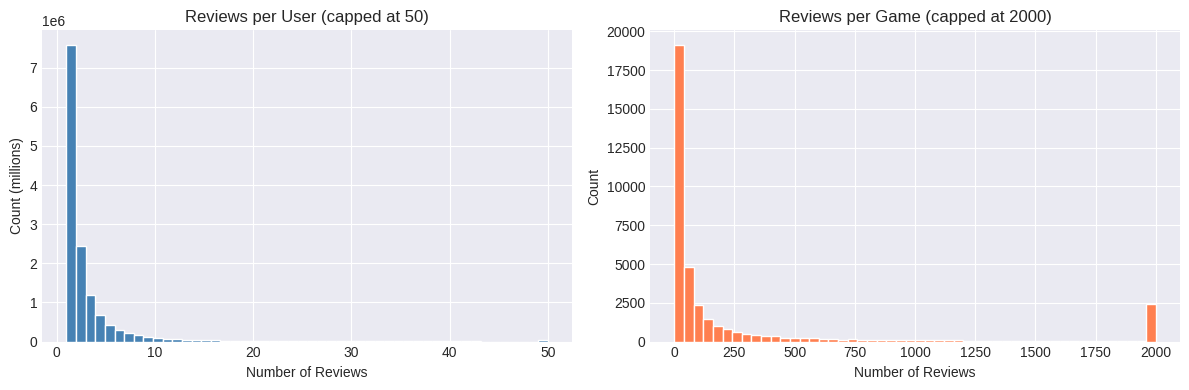

Median reviews per user: 1
Median reviews per game: 39


In [ ]:
# Distribution of reviews per user and per game
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reviews_per_user = recs.groupby('user_id').size()
reviews_per_game = recs.groupby('app_id').size()

axes[0].hist(reviews_per_user.clip(upper=50), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Reviews per User (capped at 50)')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Count (millions)')

axes[1].hist(reviews_per_game.clip(upper=2000), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Reviews per Game (capped at 2000)')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Median reviews per user: {reviews_per_user.median():.0f}')
print(f'Median reviews per game: {reviews_per_game.median():.0f}')

## Building a Rating Signal

The dataset has `is_recommended` (boolean) and `hours` (playtime). For matrix factorization, we need a numeric rating. We'll engineer one.

**Strategy:** Combine the binary recommendation signal with normalized playtime:
- `is_recommended = True` → base score of 1, scaled up by hours
- `is_recommended = False` → base score of 0, scaled down by hours
- Final rating mapped to [1, 5]

Rating distribution:
count    41154794.00
mean            3.18
std             0.43
min             1.00
25%             3.01
50%             3.05
75%             3.19
max             5.00
Name: rating, dtype: float64


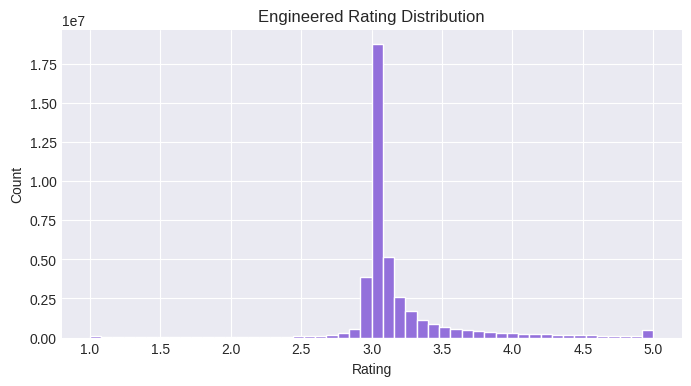

In [ ]:
# Cap hours at 99th percentile to reduce outlier influence
hours_cap = recs['hours'].quantile(0.99)
recs['hours_capped'] = recs['hours'].clip(upper=hours_cap)

# Normalize hours to [0, 1]
scaler = MinMaxScaler()
recs['hours_norm'] = scaler.fit_transform(recs[['hours_capped']])

# Build composite rating
# Recommended + high hours -> 5, Not recommended + high hours -> 1 (tried it, didn't like it)
recs['rating'] = np.where(
    recs['is_recommended'],
    3 + 2 * recs['hours_norm'],   # [3.0, 5.0] for recommended
    3 - 2 * recs['hours_norm']    # [1.0, 3.0] for not recommended
)

print('Rating distribution:')
print(recs['rating'].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(recs['rating'], bins=50, color='mediumpurple', edgecolor='white')
plt.title('Engineered Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## Filtering for a Dense Subset (K-Core)

CF algorithms suffer when users or items have very few interactions (cold start problem). We apply **k-core filtering**: keeping only users and games with at least `k` interactions.

In [ ]:
def kcore_filter(df, user_col, item_col, k=5, max_iter=10):
    """Iteratively remove users/items with fewer than k interactions."""
    for i in range(max_iter):
        n_before = len(df)
        # Keep users with >= k interactions
        user_counts = df[user_col].value_counts()
        df = df[df[user_col].isin(user_counts[user_counts >= k].index)]
        # Keep items with >= k interactions
        item_counts = df[item_col].value_counts()
        df = df[df[item_col].isin(item_counts[item_counts >= k].index)]
        if len(df) == n_before:
            break
    return df

K = 5
recs_filtered = kcore_filter(recs, 'user_id', 'app_id', k=K)

print(f'Before filtering: {len(recs):,} interactions')
print(f'After {K}-core:   {len(recs_filtered):,} interactions')
print(f'Retained users:   {recs_filtered["user_id"].nunique():,}')
print(f'Retained games:   {recs_filtered["app_id"].nunique():,}')

# Merge in game titles
recs_filtered = recs_filtered.merge(games[['app_id', 'title']], on='app_id', how='left')
print('\nSample interactions with game titles:')
recs_filtered[['user_id', 'title', 'is_recommended', 'hours', 'rating']].head(10)

Before filtering: 41,154,794 interactions
After 5-core:   22,434,177 interactions
Retained users:   1,910,450
Retained games:   34,369

Sample interactions with game titles:


,user_id,title,is_recommended,hours,rating
0,51580,Dwarf Fortress,True,36.3,3.083979
1,161081,Call of Duty®,True,46.7,3.108039
2,76583,CarX Drift Racing Online,True,177.0,3.409485
3,664486,Call of Duty®,True,7.4,3.017120
4,22793,Dying Light 2 Stay Human,True,40.6,3.093927
5,271318,theHunter: Call of the Wild™,True,10.0,3.023135
6,433335,Call of Duty®: Black Ops,False,5.9,2.986350
7,912612,VRChat,True,8.1,3.018739
8,337740,Vampire Survivors,True,55.8,3.129092
9,763450,Tom Clancy's Rainbow Six® Siege,True,166.6,3.385425


## Memory-Based Collaborative Filtering

Memory-based CF uses the user-item interaction matrix directly to compute similarities.

### Build the User-Item Matrix

In [ ]:
# For tractability, sample top users and games by interaction count
TOP_USERS = 2000
TOP_GAMES = 500

top_users = recs_filtered['user_id'].value_counts().head(TOP_USERS).index
top_games = recs_filtered['app_id'].value_counts().head(TOP_GAMES).index

matrix_df = recs_filtered[
    recs_filtered['user_id'].isin(top_users) &
    recs_filtered['app_id'].isin(top_games)
]

# Pivot to user-item matrix
user_item_matrix = matrix_df.pivot_table(
    index='user_id', columns='app_id', values='rating'
).fillna(0)

print(f'User-item matrix shape: {user_item_matrix.shape}')
print(f'Density: {(user_item_matrix > 0).sum().sum() / user_item_matrix.size:.4%}')

User-item matrix shape: (1996, 500)
Density: 11.9324%


### Item-Based CF

Item-based CF finds games that are rated similarly by the same users. The similarity between items is computed using cosine similarity on the item vectors.

In [ ]:
# Compute item-item cosine similarity
item_matrix = csr_matrix(user_item_matrix.T.values)  # items x users
item_sim = cosine_similarity(item_matrix)
item_sim_df = pd.DataFrame(
    item_sim,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

# Build app_id -> title lookup
id_to_title = games.set_index('app_id')['title'].to_dict()

def get_similar_games_cf(app_id, n=10):
    """Return top-N most similar games by item-based CF."""
    if app_id not in item_sim_df.index:
        return f'Game {app_id} not in matrix'
    sims = item_sim_df[app_id].drop(app_id).sort_values(ascending=False).head(n)
    results = pd.DataFrame({
        'app_id': sims.index,
        'title': [id_to_title.get(i, 'Unknown') for i in sims.index],
        'similarity': sims.values
    })
    return results

# Find games similar to a popular title in the matrix
sample_game = top_games[0]  # most-reviewed game in our filtered set
print(f"Games similar to: '{id_to_title.get(sample_game, sample_game)}'\n")
get_similar_games_cf(sample_game)

Games similar to: 'Team Fortress 2'



,app_id,title,similarity
0,550,Left 4 Dead 2,0.489103
1,220,Half-Life 2,0.460426
2,240,Counter-Strike: Source,0.455686
3,1250,Killing Floor,0.450313
4,304930,Unturned,0.437954
5,49520,Borderlands 2,0.431061
6,620,Portal 2,0.412250
7,400,Portal,0.411080
8,380,Half-Life 2: Episode One,0.409291
9,500,Left 4 Dead,0.408384


## Exercise: Find Similar Games

Use the search cell below to find a game you know, then use its `app_id` to get similar game recommendations based on how users rated them.

In [ ]:
search_query = "Call of Duty®: Black Ops II"

results = games[games['title'].str.contains(search_query, case=False, na=False)]
print(results[['app_id', 'title']].head(10).to_string(index=False))

 app_id                                                                 title
 274123     Call of Duty®: Black Ops II - Weaponized 115 Personalization Pack
 202970                                           Call of Duty®: Black Ops II
 660850              Call of Duty®: Black Ops III - C.O.D.E. Double Duty Pack
 311210                                          Call of Duty®: Black Ops III
 426730 Call of Duty®: Black Ops III - C.O.D.E. Warriors Personalization Pack
 234788             Call of Duty®: Black Ops II - Cyborg Personalization Pack
 234771         Call of Duty®: Black Ops II - Party Rock Personalization Pack
 234775          Call of Duty®: Black Ops II - Benjamins Personalization Pack
 234791       Call of Duty®: Black Ops II - Pack-A-Punch Personalization Pack
 234770                        Call of Duty®: Black Ops II - Extra Slots Pack


In [ ]:
my_game_id = 202970

print(f"Games similar to '{id_to_title.get(my_game_id)}':\n")
get_similar_games_cf(my_game_id)

Games similar to 'Call of Duty®: Black Ops II':



,app_id,title,similarity
0,42700,Call of Duty®: Black Ops,0.589299
1,42680,Call of Duty®: Modern Warfare® 3 (2011),0.529495
2,10180,Call of Duty®: Modern Warfare® 2 (2009),0.514780
3,311210,Call of Duty®: Black Ops III,0.492811
4,10090,Call of Duty: World at War,0.479324
5,292730,Call of Duty®: Infinite Warfare,0.442211
6,220240,Far Cry 3,0.377385
7,476600,Call of Duty®: WWII,0.356764
8,203140,Hitman: Absolution™,0.354215
9,12210,Grand Theft Auto IV: The Complete Edition,0.348715


### User-Based CF

User-based CF finds similar users and recommends games those users liked that the target user hasn't played.

In [ ]:
# Compute user-user cosine similarity
user_matrix = csr_matrix(user_item_matrix.values)  # users x items
user_sim = cosine_similarity(user_matrix)
user_sim_df = pd.DataFrame(
    user_sim,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

def recommend_for_user(user_id, n_neighbors=20, n_recs=10):
    """
    User-based CF: find similar users, aggregate their ratings,
    and recommend games the target user hasn't played.
    """
    if user_id not in user_sim_df.index:
        return f'User {user_id} not in matrix'

    # Games the target user already interacted with
    played = set(user_item_matrix.columns[
        user_item_matrix.loc[user_id] > 0
    ])

    # Top-N similar users
    similar_users = (
        user_sim_df[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_neighbors)
        .index
    )

    # Weighted average of similar users' ratings for unseen games
    neighbor_ratings = user_item_matrix.loc[similar_users]
    weights = user_sim_df.loc[similar_users, user_id].values
    weighted_scores = neighbor_ratings.T.dot(weights) / (weights.sum() + 1e-9)

    # Exclude already-played games
    recommendations = (
        weighted_scores
        .drop(labels=[i for i in played if i in weighted_scores.index])
        .sort_values(ascending=False)
        .head(n_recs)
    )

    return pd.DataFrame({
        'app_id': recommendations.index,
        'title': [id_to_title.get(i, 'Unknown') for i in recommendations.index],
        'predicted_score': recommendations.values
    })

# Test on a sample user
sample_user = user_item_matrix.index[0]
print(f'Recommendations for user {sample_user}:\n')
recommend_for_user(sample_user)

Recommendations for user 1239:



,app_id,title,predicted_score
0,883710,Resident Evil 2,2.370025
1,307690,Sleeping Dogs: Definitive Edition,2.296155
2,750920,Shadow of the Tomb Raider: Definitive Edition,1.953385
3,403640,Dishonored 2,1.950395
4,782330,DOOM Eternal,1.912834
5,379720,DOOM,1.890097
6,205100,Dishonored,1.888241
7,460790,Bayonetta,1.875173
8,287700,METAL GEAR SOLID V: THE PHANTOM PAIN,1.819857
9,418370,Resident Evil 7 Biohazard,1.765374


## Model-Based CF with Matrix Factorization (SVD)

**Matrix Factorization**: decomposes the user-item matrix into two low-rank matrices:
- **User factors:** What types of games does each user prefer?
- **Item factors:** What latent qualities does each game have?

We use **SVD** (Singular Value Decomposition) via the `Surprise` library.

In [ ]:
# Prepare data for Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(
    recs_filtered[['user_id', 'app_id', 'rating']].sample(n=min(200000, len(recs_filtered)), random_state=42),
    reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print(f'Train size: {trainset.n_ratings:,}')
print(f'Test size:  {len(testset):,}')

Train size: 160,000
Test size:  40,000


In [ ]:
# Train SVD
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)

# Evaluate on test set
predictions = svd.test(testset)
rmse = accuracy.rmse(predictions)
mae  = accuracy.mae(predictions)
print(f'\nSVD RMSE: {rmse:.4f}')
print(f'SVD MAE:  {mae:.4f}')

RMSE: 0.3344
MAE:  0.1745

SVD RMSE: 0.3344
SVD MAE:  0.1745


In [ ]:
# Cross-validate SVD
cv_results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.3287  0.3351  0.3296  0.3312  0.0028  
MAE (testset)     0.1727  0.1748  0.1727  0.1734  0.0010  
Fit time          2.86    2.69    3.70    3.08    0.44    
Test time         0.37    0.39    0.36    0.38    0.01    


### SVD Recommendations

In [ ]:
def svd_recommend(user_id, n=10):
    """
    Use the trained SVD model to predict ratings for all unplayed games
    and return top-N recommendations.
    """
    # Games this user has already interacted with
    played_ids = set(
        recs_filtered[recs_filtered['user_id'] == user_id]['app_id']
    )

    # Predict on all games not yet played
    all_games = recs_filtered['app_id'].unique()
    unseen = [g for g in all_games if g not in played_ids]

    preds = [(g, svd.predict(user_id, g).est) for g in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)

    top = preds[:n]
    return pd.DataFrame({
        'app_id': [p[0] for p in top],
        'title':  [id_to_title.get(p[0], 'Unknown') for p in top],
        'predicted_rating': [round(p[1], 3) for p in top]
    })

# Test
sample_user_svd = recs_filtered['user_id'].value_counts().index[5]
print(f'SVD Recommendations for user {sample_user_svd}:\n')
svd_recommend(sample_user_svd)

SVD Recommendations for user 5390510:



,app_id,title,predicted_rating
0,629520,Soundpad,3.618
1,236850,Europa Universalis IV,3.583
2,39210,FINAL FANTASY XIV Online,3.578
3,294100,RimWorld,3.576
4,440,Team Fortress 2,3.573
5,105600,Terraria,3.555
6,107410,Arma 3,3.551
7,1454400,Cookie Clicker,3.537
8,427520,Factorio,3.534
9,394360,Hearts of Iron IV,3.519


## Evaluation: Precision@K and Recall@K

RMSE measures rating accuracy, but what we really care about is **ranking quality**.

- **Precision@K**: Of the top-K recommended items, what fraction did the user actually like?
- **Recall@K**: Of all items the user liked, what fraction appear in the top-K recommendations?

In [ ]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Compute Precision@K and Recall@K averaged over all users.
    A prediction is 'relevant' if the true rating >= threshold.
    """
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_relevant       = sum(1 for (_, r) in user_ratings if r >= threshold)
        n_rec_k          = min(k, len(user_ratings))
        n_relevant_and_rec_k = sum(
            1 for (_, r) in user_ratings[:k] if r >= threshold
        )
        precisions[uid] = n_relevant_and_rec_k / n_rec_k if n_rec_k else 0
        recalls[uid]    = n_relevant_and_rec_k / n_relevant if n_relevant else 0

    avg_precision = sum(precisions.values()) / len(precisions)
    avg_recall    = sum(recalls.values())    / len(recalls)
    return avg_precision, avg_recall

for k in [5, 10, 20]:
    p, r = precision_recall_at_k(predictions, k=k, threshold=3.5)
    f1   = 2 * p * r / (p + r + 1e-9)
    print(f'K={k:2d}  |  Precision@K: {p:.4f}  |  Recall@K: {r:.4f}  |  F1@K: {f1:.4f}')

K= 5  |  Precision@K: 0.0889  |  Recall@K: 0.0902  |  F1@K: 0.0895
K=10  |  Precision@K: 0.0889  |  Recall@K: 0.0902  |  F1@K: 0.0895
K=20  |  Precision@K: 0.0889  |  Recall@K: 0.0902  |  F1@K: 0.0895


## Content-Based Filtering (Review)

Lightweight content-based recommender using the game metadata (tags + description), then combine it with our CF model for a hybrid system.

In [ ]:
with open(os.path.join(path, 'games_metadata.json'), 'r') as f:
    metadata_raw = [json.loads(line) for line in f if line.strip()]

# Normalize to DataFrame
# Each line is a JSON object with app_id, description, tags
metadata = pd.DataFrame([
    {'app_id': int(obj['app_id']), 'description': obj.get('description', ''), 'tags': obj.get('tags', [])}
    for obj in metadata_raw
])

# Join with game titles
metadata = metadata.merge(games[['app_id', 'title', 'rating', 'positive_ratio']], on='app_id', how='inner')

# Build a text soup: tags + description
metadata['tags_str'] = metadata['tags'].apply(
    lambda t: ' '.join(t) if isinstance(t, list) else ''
)
metadata['content'] = metadata['tags_str'] + ' ' + metadata['description'].fillna('')

print(f'Metadata entries: {len(metadata):,}')
metadata[['title', 'tags_str', 'description']].head(3)

Metadata entries: 50,872


,title,tags_str,description
0,Prince of Persia: Warrior Within™,Action Adventure Parkour Third Person Great Soundtrack S...,Enter the dark underworld of Prince of Persia Warrior Wi...
1,BRINK: Agents of Change,Action,
2,Monaco: What's Yours Is Mine,Co-op Stealth Indie Heist Local Co-Op Strategy Online Co...,Monaco: What's Yours Is Mine is a single player or co-op...


In [ ]:
# TF-IDF on content — only keep games that appear in recs_filtered to avoid
# computing similarity for ~50k games we never actually recommend from
active_app_ids = set(recs_filtered['app_id'].unique())
metadata_filtered = metadata[metadata['app_id'].isin(active_app_ids)].reset_index(drop=True)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(metadata_filtered['content'])

# Don't materialize the full dense similarity matrix — store the sparse TF-IDF
# matrix and compute similarities on-demand per query game instead
content_sim_df = None  # replaced below by lookup function
_tfidf_index = {app_id: i for i, app_id in enumerate(metadata_filtered['app_id'])}
_tfidf_app_ids = metadata_filtered['app_id'].values

def get_content_sim_row(app_id):
    """Compute cosine similarity for one game against all others on demand."""
    idx = _tfidf_index.get(app_id)
    if idx is None:
        return None
    row = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    return row

def content_recommend(app_id, n=10):
    """Content-based recommendations using TF-IDF on tags + description."""
    if app_id not in _tfidf_index:
        return f'Game {app_id} not in metadata'
    row = get_content_sim_row(app_id)
    if row is None:
        return f'Game {app_id} not found in content index'
    sims_series = pd.Series(row, index=_tfidf_app_ids)
    sims = sims_series.drop(app_id, errors='ignore').sort_values(ascending=False).head(n)
    return pd.DataFrame({
        'app_id': sims.index,
        'title': [id_to_title.get(i, 'Unknown') for i in sims.index],
        'content_similarity': sims.values
    })

# Test
sample_game_meta = metadata['app_id'].iloc[0]
print(f"Content-based recommendations for: '{id_to_title.get(sample_game_meta)}'\n")
content_recommend(sample_game_meta)

Content-based recommendations for: 'Prince of Persia: Warrior Within™'



,app_id,title,content_similarity
0,33320,Prince of Persia: The Forgotten Sands™,0.419440
1,13600,Prince of Persia®: The Sands of Time,0.415710
2,19980,Prince of Persia®,0.410959
3,13530,Prince of Persia: The Two Thrones™,0.409636
4,224940,Legacy of Kain: Soul Reaver 2,0.323549
5,2135990,Ringlorn Saga,0.253723
6,1695480,Hellblusser,0.253025
7,545830,Princess of Tavern Collector's Edition,0.252811
8,1249070,AeternoBlade II: Director's Rewind,0.244781
9,858050,The Rose of Segunda,0.242784


## Hybrid Recommender

A hybrid recommender combines **CF signals** (what similar users liked) with **content signals** (what's similar to games you liked).

The content score is derived by averaging content similarity to the user's top-rated games.

In [ ]:
def hybrid_recommend(user_id, alpha=0.7, n=10):
    """
    Hybrid recommender combining SVD (CF) and content-based filtering.

    Parameters
    ----------
    user_id : int
    alpha   : float, weight for CF score (1-alpha goes to content)
    n       : int, number of recommendations
    """
    # --- CF component: predict ratings for unseen games ---
    played_ids = set(recs_filtered[recs_filtered['user_id'] == user_id]['app_id'])
    all_games  = recs_filtered['app_id'].unique()
    unseen     = [g for g in all_games if g not in played_ids]

    cf_scores = {g: svd.predict(user_id, g).est for g in unseen}

    # Normalize CF scores to [0, 1]
    cf_min, cf_max = min(cf_scores.values()), max(cf_scores.values())
    cf_norm = {g: (s - cf_min) / (cf_max - cf_min + 1e-9) for g, s in cf_scores.items()}

    # --- Content component: similarity to user's top-rated played games ---
    user_ratings = (
        recs_filtered[recs_filtered['user_id'] == user_id]
        .sort_values('rating', ascending=False)
        .head(5)['app_id']
        .tolist()
    )

    # Precompute similarity rows for each of the user's top-rated games
    liked_sim_rows = {}
    for liked in user_ratings:
        row = get_content_sim_row(liked)
        if row is not None:
            liked_sim_rows[liked] = pd.Series(row, index=_tfidf_app_ids)

    content_scores = {}
    for g in unseen:
        sims = [
            row[g]
            for row in liked_sim_rows.values()
            if g in row.index
        ]
        content_scores[g] = np.mean(sims) if sims else 0.0

    # --- Combine ---
    hybrid_scores = {
        g: alpha * cf_norm.get(g, 0) + (1 - alpha) * content_scores.get(g, 0)
        for g in unseen
    }

    top = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame({
        'app_id':       [t[0] for t in top],
        'title':        [id_to_title.get(t[0], 'Unknown') for t in top],
        'hybrid_score': [round(t[1], 4) for t in top]
    })

# Test
print(f'Hybrid Recommendations for user {sample_user_svd}:\n')
hybrid_recommend(sample_user_svd, alpha=0.7)

Hybrid Recommendations for user 5390510:



,app_id,title,hybrid_score
0,629520,Soundpad,0.7179
1,236850,Europa Universalis IV,0.6736
2,39210,FINAL FANTASY XIV Online,0.6698
3,294100,RimWorld,0.6685
4,440,Team Fortress 2,0.6661
5,105600,Terraria,0.6526
6,107410,Arma 3,0.6494
7,1454400,Cookie Clicker,0.6433
8,427520,Factorio,0.6368
9,394360,Hearts of Iron IV,0.6253


### Compare CF vs. Hybrid Side-by-Side

In [ ]:
cf_recs = svd_recommend(sample_user_svd, n=10)
hybrid_recs = hybrid_recommend(sample_user_svd, alpha=0.7, n=10)

comparison = cf_recs[['title']].rename(columns={'title': 'CF (SVD)'})
comparison['Hybrid (α=0.7)'] = hybrid_recs['title'].values
comparison.index = range(1, 11)
comparison.index.name = 'Rank'
comparison

,CF (SVD),Hybrid (α=0.7)
Rank,,
1,Soundpad,Soundpad
2,Europa Universalis IV,Europa Universalis IV
3,FINAL FANTASY XIV Online,FINAL FANTASY XIV Online
4,RimWorld,RimWorld
5,Team Fortress 2,Team Fortress 2
6,Terraria,Terraria
7,Arma 3,Arma 3
8,Cookie Clicker,Cookie Clicker
9,Factorio,Factorio


### Tuning Alpha

Alpha controls the CF/content tradeoff. Let's see how varying alpha changes the overlap with pure CF.

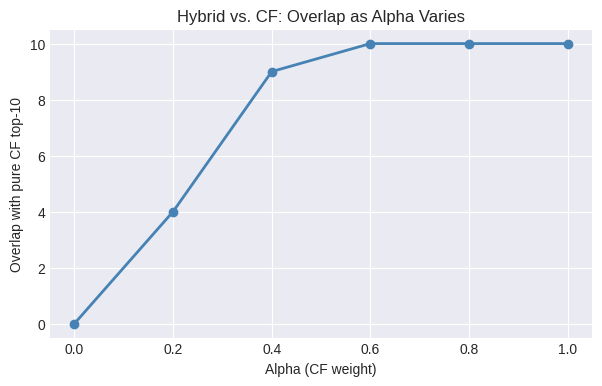

In [ ]:
cf_set = set(cf_recs['app_id'])
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
overlaps = []

for a in alphas:
    hybrid = hybrid_recommend(sample_user_svd, alpha=a, n=10)
    overlap = len(set(hybrid['app_id']) & cf_set)
    overlaps.append(overlap)

plt.figure(figsize=(7, 4))
plt.plot(alphas, overlaps, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Alpha (CF weight)')
plt.ylabel('Overlap with pure CF top-10')
plt.title('Hybrid vs. CF: Overlap as Alpha Varies')
plt.xticks(alphas)
plt.ylim(-0.5, 10.5)
plt.grid(True)
plt.show()

## Cold Start Analysis

Challenge: what do we recommend to **new users** with no interaction history?

In [ ]:
def cold_start_recommend(n=10, strategy='popularity'):
    """
    Fallback recommender for new users.

    Strategies:
      'popularity' - most reviewed games
      'rating'     - highest rated games (min review threshold)
    """
    if strategy == 'popularity':
        return (
            games.sort_values('user_reviews', ascending=False)
            .head(n)[['app_id', 'title', 'user_reviews', 'positive_ratio']]
            .reset_index(drop=True)
        )
    elif strategy == 'rating':
        return (
            games[games['user_reviews'] >= 1000]
            .sort_values('positive_ratio', ascending=False)
            .head(n)[['app_id', 'title', 'user_reviews', 'positive_ratio']]
            .reset_index(drop=True)
        )

print('=== Popularity-based (new user fallback) ===')
print(cold_start_recommend(strategy='popularity').to_string(index=False))
print('\n=== Rating-based (new user fallback) ===')
print(cold_start_recommend(strategy='rating').to_string(index=False))

=== Popularity-based (new user fallback) ===
 app_id                            title  user_reviews  positive_ratio
    730 Counter-Strike: Global Offensive       7494460              88
 578080              PUBG: BATTLEGROUNDS       2217226              57
    570                           Dota 2       2045628              82
 271590               Grand Theft Auto V       1484122              86
 359550  Tom Clancy's Rainbow Six® Siege        993312              86
    440                  Team Fortress 2        985819              93
 105600                         Terraria        943413              97
   4000                      Garry's Mod        853733              96
 252490                             Rust        786668              87
1172470                    Apex Legends™        713182              80

=== Rating-based (new user fallback) ===
 app_id                               title  user_reviews  positive_ratio
1307580                                TOEM          2321 